In [18]:
%config InlineBackend.figure_formats = ['svg']
import numpy as np  # noqa
import matplotlib as mpl  # noqa
import matplotlib.pyplot as plt  # noqa
import quimb as qu  # noqa
import xyzpy as xyz  # noqa
import autoray as ar  # noqa
import cotengra as ctg  # noqa
import quimb.tensor as qtn  # noqa

mpl.style.use(xyz.get_neutral_style(draw_color="black"))
import sys

sys.path.append("..")
import simpclustlib

mpl.rcParams["font.family"] = "Inter"

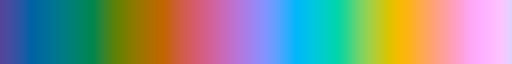

In [19]:
Ds = [2, 3, 4, 5, 6, 7, 8, 10, 12, 14, 16]
cm = xyz.cmoke((0.8, 0.8 - 2), val1=0.45)
cm

In [20]:
colors = dict(zip(Ds, cm(np.linspace(1.0, 0.0, len(Ds)))))
markers = dict(
    zip(
        Ds,
        (
            "o",
            "X",
            "v",
            "s",
            "P",
            "D",
            "^",
            "h",
            "*",
            "p",
            "<",
            "d",
            "8",
            ">",
            "H",
        ),
    )
)

In [21]:
linewidth_prod = 1
linewidth_sum = 1

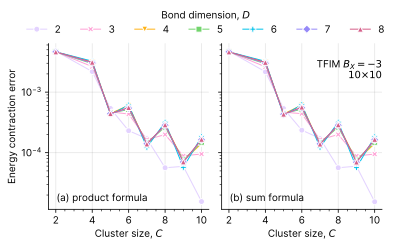

In [22]:
yvar = "energy_gloop_expand"

fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(6, 3), sharey=True)
plt.subplots_adjust(wspace=0.08, hspace=0.08)

handles = {}

model = "tfim_hz-3"
geom = "square_obc"
selector = dict(
    symm="Z2",
    site_charge="uniform-0",
)
ds_ref = (
    xyz.load_ds(f"../data/energy_full_{model}_{geom}.h5")
    .sel(**selector)
    .squeeze()
)
simpclustlib.estimate_full_stats_into_ds(ds_ref, mode="wynn", plot=False)
ds_glx = (
    xyz.load_ds(f"../data/energy_gloop_expand_{model}_{geom}.h5")
    .sel(**selector)
    .squeeze()
)
ds_glx["max_size"] = ds_glx["max_size"].clip(2, None)

ds_glx["contraction_error"] = abs(1 - ds_glx[yvar] / ds_ref["energy_estimate"])

ax = axs[0]

for D in [2, 3, 4, 5, 6, 7, 8]:
    sds = ds_glx.sel(L=10, D=D)
    x = sds["max_size"].values
    y = sds["contraction_error"].values
    (handles[D],) = ax.plot(
        x,
        y,
        color=colors[D],
        marker=markers[D],
        markeredgecolor="white",
        label=f"{D}",
        linewidth=linewidth_prod,
    )

ax.set(
    yscale="log",
    xlabel="Cluster size, $C$",
    ylabel="Energy contraction error",
)
ax.text(0.05, 0.05, "(a) product formula", transform=ax.transAxes)

yvar = "energy_gloop_expand_norm_sum"
row = 1

model = "tfim_hz-3"
geom = "square_obc"
selector = dict(
    symm="Z2",
    site_charge="uniform-0",
)
ds_ref = (
    xyz.load_ds(f"../data/energy_full_{model}_{geom}.h5")
    .sel(**selector)
    .squeeze()
)
simpclustlib.estimate_full_stats_into_ds(ds_ref, mode="wynn", plot=False)
ds_glx = (
    xyz.load_ds(f"../data/energy_gloop_expand_{model}_{geom}.h5")
    .sel(**selector)
    .squeeze()
)
ds_glx["max_size"] = ds_glx["max_size"].clip(2, None)

ds_glx["contraction_error"] = abs(1 - ds_glx[yvar] / ds_ref["energy_estimate"])


ax = axs[1]

for D in [2, 3, 4, 5, 6, 7, 8]:
    sds = ds_glx.sel(L=10, D=D)
    x = sds["max_size"].values
    y = sds["contraction_error"].values
    (handles[D],) = ax.plot(
        x,
        y,
        color=colors[D],
        # marker="",
        # linewidth=0.75,
        # linestyle=':',
        marker=markers[D],
        linewidth=linewidth_sum,
        linestyle="-",
        markeredgecolor="white",
        label=f"{D}",
    )

ax.set(
    yscale="log",
    xlabel="Cluster size, $C$",
    # ylabel="Energy contraction error",
    # hide ticklabels:
    # yticklabels=[],
)
ax.text(0.05, 0.05, "(b) sum formula", transform=ax.transAxes)

ax.legend(
    handles=list(handles.values()),
    ncol=7,
    bbox_to_anchor=(-0.1, 1.0),
    loc="lower center",
    # bbox_to_anchor=(1.0, 1.0), loc="upper left",
    title="Bond dimension, $D$",
)

ax.text(
    1.0,
    0.9,
    "TFIM $B_X{{=}}{{-}}3$\n      $10{{\\times}}10$",
    ha="right",
    va="top",
    transform=ax.transAxes,
)

plt.show()
plt.close()

In [23]:
fig.savefig(
    "fig-energy-contraction-error-square-obc-tfim.png",
    dpi=300,
    bbox_inches="tight",
)

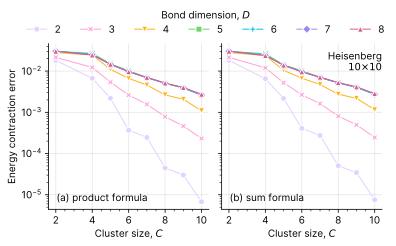

In [24]:
yvar = "energy_gloop_expand"

fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(6, 3), sharey=True)
plt.subplots_adjust(wspace=0.08, hspace=0.08)

handles = {}

model = "heis"
geom = "square_obc"
selector = dict(
    symm="U1",
)
ds_ref = (
    xyz.load_ds(f"../data/energy_full_{model}_{geom}.h5")
    .sel(**selector)
    .squeeze()
)
simpclustlib.estimate_full_stats_into_ds(ds_ref, mode="wynn", plot=False)
ds_glx = (
    xyz.load_ds(f"../data/energy_gloop_expand_{model}_{geom}.h5")
    .sel(**selector)
    .squeeze()
)
ds_glx["max_size"] = ds_glx["max_size"].clip(2, None)

ds_glx["contraction_error"] = abs(1 - ds_glx[yvar] / ds_ref["energy_estimate"])

ax = axs[0]

for D in [2, 3, 4, 5, 6, 7, 8]:
    sds = ds_glx.sel(L=10, D=D)
    x = sds["max_size"].values
    y = sds["contraction_error"].values
    (handles[D],) = ax.plot(
        x,
        y,
        color=colors[D],
        marker=markers[D],
        markeredgecolor="white",
        label=f"{D}",
        linewidth=linewidth_prod,
    )

ax.set(
    yscale="log",
    xlabel="Cluster size, $C$",
    ylabel="Energy contraction error",
)
ax.text(0.05, 0.05, "(a) product formula", transform=ax.transAxes)

yvar = "energy_gloop_expand_norm_sum"

model = "heis"
geom = "square_obc"
selector = dict(
    symm="U1",
)
ds_ref = (
    xyz.load_ds(f"../data/energy_full_{model}_{geom}.h5")
    .sel(**selector)
    .squeeze()
)
simpclustlib.estimate_full_stats_into_ds(ds_ref, mode="wynn", plot=False)
ds_glx = (
    xyz.load_ds(f"../data/energy_gloop_expand_{model}_{geom}.h5")
    .sel(**selector)
    .squeeze()
)
ds_glx["max_size"] = ds_glx["max_size"].clip(2, None)

ds_glx["contraction_error"] = abs(1 - ds_glx[yvar] / ds_ref["energy_estimate"])


ax = axs[1]

for D in [2, 3, 4, 5, 6, 7, 8]:
    sds = ds_glx.sel(L=10, D=D)
    x = sds["max_size"].values
    y = sds["contraction_error"].values
    (handles[D],) = ax.plot(
        x,
        y,
        color=colors[D],
        # marker="",
        # linewidth=0.75,
        # linestyle=':',
        marker=markers[D],
        linewidth=linewidth_sum,
        linestyle="-",
        markeredgecolor="white",
        label=f"{D}",
    )

ax.set(
    yscale="log",
    xlabel="Cluster size, $C$",
    # ylabel="Energy contraction error",
    # hide ticklabels:
    # yticklabels=[],
)
ax.text(0.05, 0.05, "(b) sum formula", transform=ax.transAxes)

ax.legend(
    handles=list(handles.values()),
    ncol=7,
    bbox_to_anchor=(-0.1, 1.0),
    loc="lower center",
    # bbox_to_anchor=(1.0, 1.0), loc="upper left",
    title="Bond dimension, $D$",
)

ax.text(
    1.0,
    0.95,
    "Heisenberg\n      $10{{\\times}}10$",
    ha="right",
    va="top",
    transform=ax.transAxes,
)

plt.show()
plt.close()

In [25]:
fig.savefig(
    "fig-energy-contraction-error-square-obc-heis.png",
    dpi=300,
    bbox_inches="tight",
)

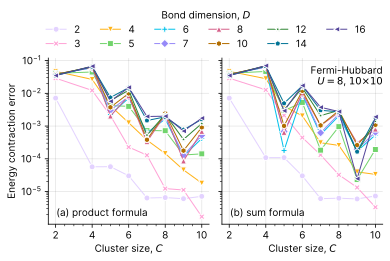

In [26]:
yvar = "energy_gloop_expand"

fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(6, 3), sharey=True)
plt.subplots_adjust(wspace=0.08, hspace=0.08)

handles = {}

model = "fermi_hubbard_U8"
selector = dict(
    symm="U1",
    site_charge="uniform-1",
)
ds_ref = (
    xyz.load_ds(f"../data/energy_full_{model}_{geom}.h5")
    .sel(**selector)
    .squeeze()
)
simpclustlib.estimate_full_stats_into_ds(ds_ref, mode="wynn", plot=False)
ds_glx = (
    xyz.load_ds(f"../data/energy_gloop_expand_{model}_{geom}.h5")
    .sel(**selector)
    .squeeze()
)
ds_glx["max_size"] = ds_glx["max_size"].clip(2, None)

ds_glx["contraction_error"] = abs(1 - ds_glx[yvar] / ds_ref["energy_estimate"])

ax = axs[0]

for D in [2, 3, 4, 5, 6, 7, 8, 10, 12, 14, 16]:
    sds = ds_glx.sel(L=10, D=D)
    x = sds["max_size"].values
    y = sds["contraction_error"].values
    (handles[D],) = ax.plot(
        x,
        y,
        color=colors[D],
        marker=markers[D],
        markeredgecolor="white",
        label=f"{D}",
        linewidth=linewidth_prod,
    )

ax.set(
    yscale="log",
    xlabel="Cluster size, $C$",
    ylabel="Energy contraction error",
)
ax.text(0.05, 0.05, "(a) product formula", transform=ax.transAxes)

yvar = "energy_gloop_expand_norm_sum"


ds_ref = (
    xyz.load_ds(f"../data/energy_full_{model}_{geom}.h5")
    .sel(**selector)
    .squeeze()
)
simpclustlib.estimate_full_stats_into_ds(ds_ref, mode="wynn", plot=False)
ds_glx = (
    xyz.load_ds(f"../data/energy_gloop_expand_{model}_{geom}.h5")
    .sel(**selector)
    .squeeze()
)
ds_glx["max_size"] = ds_glx["max_size"].clip(2, None)

ds_glx["contraction_error"] = abs(1 - ds_glx[yvar] / ds_ref["energy_estimate"])


ax = axs[1]

for D in [2, 3, 4, 5, 6, 7, 8, 10, 12, 14, 16]:
    sds = ds_glx.sel(L=10, D=D)
    x = sds["max_size"].values
    y = sds["contraction_error"].values
    (handles[D],) = ax.plot(
        x,
        y,
        color=colors[D],
        # marker="",
        # linewidth=0.75,
        # linestyle=':',
        marker=markers[D],
        linewidth=linewidth_sum,
        linestyle="-",
        markeredgecolor="white",
        label=f"{D}",
    )

ax.set(
    yscale="log",
    xlabel="Cluster size, $C$",
    # ylabel="Energy contraction error",
    # hide ticklabels:
    # yticklabels=[],
)
ax.text(0.05, 0.05, "(b) sum formula", transform=ax.transAxes)

ax.legend(
    handles=list(handles.values()),
    ncol=6,
    bbox_to_anchor=(-0.1, 1.0),
    loc="lower center",
    # bbox_to_anchor=(1.0, 1.0), loc="upper left",
    title="Bond dimension, $D$",
)

ax.text(
    1.0,
    0.95,
    "Fermi-Hubbard\n      $U{{=}}8$, $10{{\\times}}10$",
    ha="right",
    va="top",
    transform=ax.transAxes,
)

plt.show()
plt.close()

In [27]:
fig.savefig(
    "fig-energy-contraction-error-square-obc-fmhb.png",
    dpi=300,
    bbox_inches="tight",
)